# 05 - RAG Pipeline

Adım 8: kurgusal fraud politikalarından bilgi tabanı -> embedding (bge-m3) -> FAISS vektör araması -> yerel LLM'e (qwen2.5:3b, Ollama)
context injection -> atıf doğrulama. İşlem açıklamasında (reasoning akışı) tetiklenen kuralların `policy_ref` kodları ilgili politikaları
doğrudan getirir, anlamsal arama ek politikaları bulur.

Politikalar kurgusal: LLM'in "72 saat", "gölge mod" gibi bilgileri önceden bilmesi mümkün değil; cevapta geçiyorsa RAG çalışıyor demektir.

Ön koşul: `ollama pull qwen2.5:3b`, `ollama pull bge-m3`, `python scripts/build_index.py`, `python scripts/eval_rag.py`.

In [1]:
import json
import logging

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

from fraud_platform.config import PROJECT_ROOT, get_settings
from fraud_platform.rag.chunker import chunk_directory
from fraud_platform.rag.embedder import TfidfEmbedder
from fraud_platform.rag.factory import load_pipeline
from fraud_platform.rag.vector_store import FaissVectorStore
from fraud_platform.rules.engine import RuleEngine

logging.disable(logging.INFO)
pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid")
IMG = PROJECT_ROOT / "docs" / "images"
settings = get_settings()

## 1. Bilgi tabanı ve kural eşleşmesi

In [2]:
chunks = chunk_directory(settings.rag.knowledge_base_dir, settings.rag.max_chunk_words)
kb = pd.DataFrame([{"kod": c.policy_code, "başlık": c.title, "doküman": c.source, "kelime": len(c.text.split())} for c in chunks])
print(f"{len(chunks)} parça, {kb['kod'].nunique()} politika kodu, {kb['doküman'].nunique()} doküman")
kb

19 parça, 18 politika kodu, 7 doküman


,kod,başlık,doküman,kelime
0,NaN,Genel Risk Değerlendirme Politikası,01_genel_risk_politikasi.md,17
1,FP-01,Model Tabanlı Anomali Alarmları,01_genel_risk_politikasi.md,72
2,FP-30,Karar Seviyeleri ve İnceleme Süreleri,01_genel_risk_politikasi.md,71
3,FP-31,Müşteri İletişimi ve Doğrulama,01_genel_risk_politikasi.md,50
4,FP-03,İşlem Hızı (Velocity) Kontrolü,02_velocity_ve_bot.md,66
5,FP-04,Ardışık İşlem ve Harcama Patlaması,02_velocity_ve_bot.md,66
6,FP-07,Yeni Kart Politikası,03_kart_ve_cihaz.md,46
7,FP-09,Yeni Cihaz ve Hesap Ele Geçirme Şüphesi,03_kart_ve_cihaz.md,50
8,FP-12,Cihaz Paylaşımı ve Kart Test Saldırısı,03_kart_ve_cihaz.md,58
9,FP-15,Gece Yarısı ve Yurt Dışı Yüksek Tutar Protokolü,04_zaman_ve_cografya.md,42


In [3]:
# her iş kuralının policy_ref'i bilgi tabanında var mı?
engine = RuleEngine(settings.rules.rules_file)
codes = set(kb["kod"].dropna())
refs = pd.DataFrame([{"kural": r.id, "ad": r.name, "policy_ref": r.policy_ref, "bilgi tabanında": r.policy_ref in codes}
                     for r in engine.rules])
print("eksik politika:", refs.loc[~refs["bilgi tabanında"], "policy_ref"].tolist())
refs

eksik politika: []


,kural,ad,policy_ref,bilgi tabanında
0,R001,Velocity patlaması,FP-03,True
1,R002,Çok yüksek anomali skoru,FP-01,True
2,R003,Gece veya yurt dışı + yüksek tutar,FP-15,True
3,R004,Riskli e-posta domaini,FP-18,True
4,R005,Yüksek anomali skoru (alarm bütçesi),FP-01,True
5,R006,"Güvenilir müşteri, düşük tutar",FP-20,True
6,R007,Cihaz paylaşımı (kart test) + yüksek skor,FP-12,True
7,R008,Velocity yüksek,FP-03,True
8,R009,24 saatlik harcama patlaması,FP-04,True
9,R010,Yeni cihaz + kişisel sapma,FP-09,True


## 2. Embedding ve vektör araması

Aynı soru iki yöntemle aranıyor. TF-IDF (karakter n-gram) yazımı, bge-m3 anlamı eşler. Soru politika metnindeki kelimeleri kullanmıyor.

In [4]:
rag = load_pipeline(settings)
tfidf = FaissVectorStore(TfidfEmbedder()).build(chunks)
question = "Hesabı çalınmış olabilecek bir kullanıcı farklı bir telefondan büyük ödeme yaparsa ne yapılır?"
pd.concat({
    "TF-IDF": pd.DataFrame([{"kod": c.policy_code, "başlık": c.title, "benzerlik": round(s, 3)} for c, s in tfidf.search(question, 3)]),
    "bge-m3": pd.DataFrame([{"kod": c.policy_code, "başlık": c.title, "benzerlik": round(s, 3)} for c, s in rag.store.search(question, 3)]),
}, axis=1)

TF-IDF                                                    bge-m3  \
     kod                                   başlık benzerlik    kod   
0  FP-09  Yeni Cihaz ve Hesap Ele Geçirme Şüphesi     0.146  FP-09   
1  FP-12   Cihaz Paylaşımı ve Kart Test Saldırısı     0.128  FP-12   
2  FP-03           İşlem Hızı (Velocity) Kontrolü     0.127  FP-25   

                                                      
                                    başlık benzerlik  
0  Yeni Cihaz ve Hesap Ele Geçirme Şüphesi     0.636  
1   Cihaz Paylaşımı ve Kart Test Saldırısı     0.550  
2           Onaylı Yüksek Hacimli Hesaplar     0.547

## 3. Retrieval değerlendirmesi (18 soru, sorular politika metnini tekrar etmiyor)

,hit@1,hit@3,mrr
TF-IDF,0.722,0.889,0.796
bge-m3,0.833,1.000,0.907


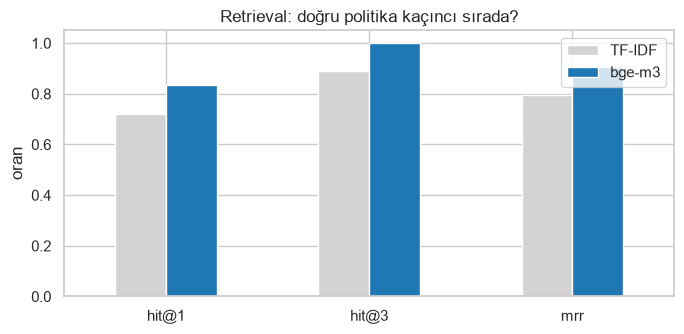

In [5]:
evaluation = json.loads((settings.rag.index_dir / "eval.json").read_text(encoding="utf-8"))
ret = pd.DataFrame(evaluation["retrieval"]).T
ret.index = ["TF-IDF", "bge-m3"]
display(ret.drop(columns="ranks").astype(float).round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
ret.drop(columns="ranks").astype(float).T.plot.bar(ax=ax, rot=0, color=["lightgray", "tab:blue"])
ax.set(title="Retrieval: doğru politika kaçıncı sırada?", ylim=(0, 1.05), ylabel="oran")
plt.tight_layout()
fig.savefig(IMG / "08_rag_retrieval.png", dpi=120)

In [6]:
questions = yaml.safe_load(settings.rag.eval_file.read_text(encoding="utf-8"))
answerable = [q for q in questions if q["expected"]]
pd.DataFrame({
    "soru": [q["question"] for q in answerable],
    "beklenen": [q["expected"] for q in answerable],
    "TF-IDF sıra": evaluation["retrieval"]["tfidf"]["ranks"],
    "bge-m3 sıra": evaluation["retrieval"]["ollama"]["ranks"],
})

,soru,beklenen,TF-IDF sıra,bge-m3 sıra
0,Model alarmıyla bloke edilen bir işlemi analist ne kadar sürede teyit etmeli?,FP-01,1.0,1
1,İnceleme kuyruğundaki bir işlem için zamanında karar verilmezse ne olur?,FP-30,1.0,1
2,Müşteriye hangi kuralın tetiklendiğini söyleyebilir miyiz?,FP-31,1.0,2
3,Bir saat içinde çok sayıda alışveriş yapan kullanıcıya ne uygulanır?,FP-03,1.0,1
4,Kısa aralıklarla art arda yapılan ödemeler nasıl ele alınır?,FP-04,NaN,1
5,Yeni aktive edilmiş bir kartla pahalı bir alışveriş yapılırsa ne olur?,FP-07,2.0,1
6,Hesabı çalınmış olabilecek bir kullanıcı farklı bir telefondan büyük ödeme yaparsa ne yapılır?,FP-09,1.0,1
7,Aynı bilgisayardan birçok farklı kartla deneme yapılıyorsa ne olur?,FP-12,1.0,1
8,Gece saatlerinde yurt dışı adresli pahalı bir sipariş geldiğinde süreç nedir?,FP-15,1.0,1
9,Hafta sonu yapılan işlemler için ayrı bir risk ayarı var mı?,FP-16,1.0,1


> **Yorum:** bge-m3 her soruda doğru politikayı ilk 3 sonuçta buldu (hit@3 1,00), TF-IDF 0,89. Sorular bilerek politika metnindeki kelimeleri
> kullanmıyor; TF-IDF kelime örtüşmesi olmayınca kaçırıyor: "kısa aralıklarla art arda ödemeler" (FP-04) ve "uzun süredir
> müşterimiz olan biri" (FP-20) sorularında doğru politikayı ilk 3'te hiç bulamadı. bge-m3'ün en zorlandığı soru blok devre kesici
> (FP-41, 3. sırada): soru "çok fazla işlem bloklanırsa" diyor, politika "devre kesici" diyor. 19 parçada brute force arama yeterli;
> büyük bir bilgi tabanında yaklaşık arama (IVF / HNSW) gerekir.

## 4. Üretim değerlendirmesi: RAG vs bağlamsız

Her soru iki kez soruldu: politikalar bağlam olarak verilerek (RAG) ve hiç bağlam verilmeden. 2 soru bilerek cevapsız
(kripto limiti, kredi başvurusu): model uydurmak yerine "bilgi yok" demeli.

In [7]:
pd.Series(evaluation["generation"]["summary"]).round(3).to_frame("oran")

,oran
cevaplanabilir: doğru politikaya atıf,0.944
cevaplanabilir: atıflar doğrulandı,0.889
cevaplanabilir: kurgusal bilgi (RAG),0.722
cevaplanabilir: kurgusal bilgi (bağlamsız),0.056
cevaplanamaz: 'bilgi yok' dedi,1.000


In [8]:
rows = pd.DataFrame(evaluation["generation"]["rows"])
show = rows.loc[rows["expected"].isin(["FP-12", "FP-42"]) | ~rows["answerable"],
                ["expected", "rag_answer", "no_context_answer", "rag_citations_verified"]]
show

,expected,rag_answer,no_context_answer,rag_citations_verified
7,FP-12,"Aynı bilgisayardan birçok farklı kartla deneme yapılırsa, işlem [FP-12] gereği FLAG olarak izlenir ve cihaz parmak izi 48 saat boyunca g...",Bilgisayarın performansı düşürebilir ve hatalar oluşabilir. Her kartın özelliklerinin uyumlu olması gereklidir.,True
16,FP-42,"Yeni bir kural canlıya alınırken, önce 4 haftalık geçmiş veri üzerinde isabet ve kapsam ölçülmesi gerekmektedir. Sonrasında kural dosyas...",Yeni bir kural canlıya alınmak için aşağıdaki adımları izleyebilirsiniz:\n\n1. **Kuralın Tanımı**: Kuralın ne anlama geldiğini açıkça be...,True
18,NaN,Politikalarda bu konuda bilgi yok.,"Kripto para borsalarında günlük transfer limitleri genellikle 10.000-50.000 dolar arasında değişmektedir. Ancak, bu limitler farklı kred...",False
19,NaN,Politikalarda bu konuda bilgi yok. [FP-16],"Gelir belgesi kredi başvurusunda genellikle zorunludur, ancak bankaların farklılık göstermesi vardır. Her banka için kontrol edilmesi ge...",True


Prompt iterasyonu (`src/fraud_platform/rag/prompts.py`): ilk sürümde "bilgi yoksa söyle" kaçışı küçük model için fazla çekiciydi
(bağlamda cevap varken bile kullanıyordu) ve cevaplar politika adını tekrar edip sayıları atlıyordu. İkinci sürüm önce ilgili politikayı
bulup sayı/süreleri aynen aktarmasını istiyor; kaçış sadece hiçbir politika ilgili değilse. Kurgusal bilgi aktarımı %50 -> %72, doğru atıf
%89 -> %94 (sıcaklık 0). Sıcaklık 0'da model bir kez tekrar döngüsüne girip 180 sn zaman aşımına uğradı: `num_predict` sınırı eklendi.
Not: prompt aynı 20 soruda iyileştirildi; bu skorlar hafif iyimserdir.

> **Yorum:** RAG ile cevapların %72'si kurgusal politikadaki ayrıntıyı (süre, limit) doğru aktarıyor; bağlamsız model %6'da tutturuyor.
> Bu farkı gösterebilmek için politikaları bilerek kurgusal yazdım. Cevapsız iki soruda RAG iki kez de "bilgi yok" dedi; bağlamsız
> model kripto transfer limiti için "10.000-50.000 dolar" uydurdu. Atıf doğrulamasından 18 cevabın 2'si geçmedi. Prompt'u aynı 20
> soruda iyileştirdiğim için bu skorlar biraz iyimser.

## 5. İşlem açıklaması (RAG tabanlı reasoning akışı)

1. İşlem skorlanır (4 katman + context), kurallar değerlendirilir
2. Tetiklenen kuralların `policy_ref` kodlarıyla politikalar doğrudan getirilir
3. Kural adları + context + katman gerekçelerinden kurulan sorguyla anlamsal arama ek politika bulur
4. LLM, kural motorunun kararını politikalara dayanarak açıklar (karar LLM'de değil, motorda)
5. Atıflar getirilen parçalara karşı doğrulanır; LLM farklı aksiyon önerirse işaretlenir

In [9]:
import time

from fraud_platform.services.scoring_service import ScoringService

service = ScoringService.from_artifacts(settings)
tx_id = 3554906
raw = pd.read_parquet(settings.merged_path, filters=[(settings.data.id_column, "==", tx_id)]).drop(columns=settings.data.target_column)
score = service.score(raw)[0]
rules = engine.evaluate(service.assessment_frame(raw).iloc[0])
print("LLM'e giden işlem özeti:\n")
print(rag.summarize(score, rules))

LLM'e giden işlem özeti:

Kural motoru kararı: BLOCK (priority_then_severity: kazanan kural R002 (Çok yüksek anomali skoru, öncelik 95, BLOCK); tetiklenen 3 kural)
Risk yüzdeliği: 0.9999 (ham 0.9996, context çarpanı 1.22)
Tetiklenen kurallar:
- R002 Çok yüksek anomali skoru -> BLOCK [FP-01]: Anomali skoru en uç %0,1'de (risk yüzdeliği 0.9999)
- R005 Yüksek anomali skoru (alarm bütçesi) -> REVIEW [FP-01]: Anomali skoru en riskli %3'te (risk yüzdeliği 0.9999)
- R008 Velocity yüksek -> FLAG [FP-03]: Kullanıcının son 1 saatte 5 işlemi daha var
Context düzeltmeleri:
- gece x1.22: Yerel 00-06 arası hacim düşük, fraud oranı ~2,7 kat; temporal katmanın nadir saat bileşeni bunu zayıf yakalıyor
Anomali katmanlarının öne çıkan gerekçeleri:
- [column] id_13 = 27.0 eğitimde hiç görülmemiş bir değer
- [column] V290 = 6, tipik değerden 39.1 robust-z uzakta (medyan 1)
- [multivariate] V302 = 4; eğitimde işlemlerin sadece %0.1'i bu kadar yüksek
- [multivariate] V52 = 4; eğitimde işlemlerin sadece %0.1'

In [10]:
start = time.time()
explanation = rag.explain_transaction(score, rules)
print(f"süre: {time.time() - start:.1f} sn\n")
print(json.dumps({k: explanation[k] for k in ["explanation", "recommended_action", "engine_decision", "llm_agrees_with_engine",
                                              "next_steps", "citations", "citations_verified", "mode"]}, indent=2, ensure_ascii=False))

süre: 6.4 sn

{
  "explanation": "Kararı BLOCK kural motoru verdi. Bu karar, model tabanlı anomali alarmlarından kaynaklanır ve bu alarmlar, işlemin geçmiş davranışına göre çok olağandışı olduğunu gösterir. Ayrıca, işlemin risk yüzdeliği 0.9999 olarak belirlenmişken, bu durumun en yüksek riskli %3'te olduğu R002 kuralı tetiklenmiştir. Bu durumda, kullanıcının geçmiş davranışına göre çok olağandışı olan bir işlem olduğundan emin olmak için REVIEW işlemi yapılmaktadır. Ancak, bu alarmların yanı sıra, Velocity kontrolünün de tetiklendiği görülmüştür ve bu durumda işlem 6 saat boyunca yeni işleme kapanmıştır. Bu nedenle, BLOCK kararının alınması önerilir.",
  "recommended_action": "BLOCK",
  "engine_decision": "BLOCK",
  "llm_agrees_with_engine": true,
  "next_steps": [
    "FP-01: Model Tabanlı Anomali Alarmları tetiklenen kurala göre REVIEW işlemi yapılır"
  ],
  "citations": [
    "FP-01"
  ],
  "citations_verified": true,
  "mode": "llm"
}


In [11]:
pd.DataFrame(explanation["sources"])[["policy_code", "title", "via", "score"]]

,policy_code,title,via,score
0,FP-01,Model Tabanlı Anomali Alarmları,policy_ref,1.0000
1,FP-03,İşlem Hızı (Velocity) Kontrolü,policy_ref,1.0000
2,FP-04,Ardışık İşlem ve Harcama Patlaması,vector,0.6294
3,FP-21,Yüksek Değerli Müşteriler,vector,0.6107


In [12]:
for step in explanation["trace"]:
    print(step)

{'step': 'policy_ref', 'codes': ['FP-01', 'FP-03']}
{'step': 'vector_search', 'query': "Çok yüksek anomali skoru; Yüksek anomali skoru (alarm bütçesi); Velocity yüksek; gece; id_13 = 27.0 eğitimde hiç görülmemiş bir değer; V302 = 4; eğitimde işlemlerin sadece %0.1'i bu kadar yüksek; Geçmişi olan kullanıcı bu cihazı ilk kez kullanıyor; Önceki işlemden 7.8 dakika sonra", 'codes': ['FP-04', 'FP-21']}
{'step': 'generate', 'mode': 'llm'}


> **Yorum:** Açıklama akışında tetiklenen kuralların politikaları (FP-01, FP-03) doğrudan geldi, vektör araması iki ek politika buldu (FP-04
> harcama patlaması, FP-21 yüksek değerli müşteri). LLM motorun BLOCK kararını FP-01'e dayanarak açıkladı, atıf doğrulandı ve
> motorla aynı aksiyonu önerdi. Ama metni dikkatle okuyunca küçük modelin sınırları görünüyor: bir yerde "REVIEW işlemi
> yapılmaktadır" diyor ve FP-03'teki "velocity bloğundan sonra kart 6 saat kapatılır" maddesini, velocity kuralı sadece FLAG olduğu
> halde uyguluyor. Atıf doğrulaması bunu yakalamıyor, çünkü içeriği değil kodu kontrol ediyor. Kararı LLM'e bırakmamamın sebebi
> bu: LLM sadece açıklıyor, karar kural motorunda.

## 6. Sınırlamalar

- 3B model: bazen sayıları bozuyor (0,999 yerine "%0,9996"), bazen kendi içinde çelişiyor (FP-25: "bloklanır; ... muaftır"),
  ALLOW kararlarında politikayı tekrarlıyor. Atıf doğrulaması kod düzeyinde; içerik doğruluğunu (çelişki) yakalamaz.
  İyileştirme: daha büyük model (qwen2.5:7b, 4 GB VRAM'e sığmıyor), içerik doğrulama için ikinci bir LLM çağrısı (NLI / self-check).
- Küçük değerlendirme seti (20 soru), prompt aynı sette iyileştirildi.
- Bilgi tabanı küçük (18 politika): ölçekte chunk boyutu, hibrit arama (BM25 + vektör) ve yeniden sıralama (reranker) gerekir.
- LLM'e ulaşılamazsa sistem çökmez: kural açıklamaları + politika başlıklarından deterministik açıklama döner (`mode: fallback`).

## 7. Özet

Üretilen çıktılar: `knowledge_base/*.md` (7 doküman, 18 politika), `artifacts/rag/` (FAISS index, parçalar, eval.json)

- Bilgi tabanı: 7 doküman, 18 kurgusal politika; kuralların policy_ref kodlarıyla birebir eşleşiyor.
- Retrieval: bge-m3 hit@3 1,00, TF-IDF 0,89; anlam eşleşmesi kelime eşleşmesinden belirgin iyi.
- Üretim: kurgusal bilgi RAG ile %72, bağlamsız %6; cevapsız sorularda %100 "bilgi yok".
- Halüsinasyon kontrolü: atıf doğrulaması kod düzeyinde çalışıyor, içerik hatasını yakalamıyor.
- Reasoning akışı: policy_ref ile doğrudan + vektör araması ile ek politika; karar kural motorunda, LLM açıklıyor.
- Sınırlamalar: 3B model sayıları ve politikaları yanlış uygulayabiliyor; değerlendirme seti küçük ve prompt aynı sette iyileştirildi.